In [8]:
import pandas as pd
import numpy as np

In [9]:
# =========================
# 1. Load model_option_A
# =========================
df = pd.read_csv("data1C/model_option_A.csv")
df["date"] = pd.to_datetime(df["date"])
df["next_date"] = pd.to_datetime(df["next_date"])
df = df.sort_values(["id", "date"]).reset_index(drop=True)

# Keep only rows with target
df = df.dropna(subset=["mood_next_day"]).copy()

In [10]:
# =========================
# 2. Select input features
# =========================
feature_cols = [
    "mood",
    "activity",
    "screen",
    "call",
    "sms",
    "circumplex.arousal",
    "circumplex.valence",
    "appCat.builtin",
    "appCat.communication",
    "appCat.entertainment",
    "appCat.finance",
    "appCat.game",
    "appCat.office",
    "appCat.other",
    "appCat.social",
    "appCat.travel",
    "appCat.unknown",
    "appCat.utilities",
    "appCat.weather"
]

feature_cols = [col for col in feature_cols if col in df.columns]

In [11]:
print(df[feature_cols].isna().sum().sum())

105


In [12]:
train_data = []
test_data = []

for patient_id, group in df.groupby("id"):
    group = group.sort_values("date").copy()

    if len(group) < 10:
        continue

    split = int(0.8 * len(group))

    if split == 0 or split == len(group):
        continue

    train_data.append(group.iloc[:split])
    test_data.append(group.iloc[split:])

train_df = pd.concat(train_data).reset_index(drop=True)
test_df = pd.concat(test_data).reset_index(drop=True)

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

Train rows: 961
Test rows: 255


In [13]:
# =========================
# 4. Convert next-day mood to classes
# =========================
low = train_df["mood_next_day"].quantile(0.33)
high = train_df["mood_next_day"].quantile(0.67)

def mood_to_class(x):
    if x <= low:
        return 0
    elif x <= high:
        return 1
    else:
        return 2

train_df["mood_class_next_day"] = train_df["mood_next_day"].apply(mood_to_class)
test_df["mood_class_next_day"] = test_df["mood_next_day"].apply(mood_to_class)

print(train_df["mood_class_next_day"].value_counts())
print(test_df["mood_class_next_day"].value_counts())

mood_class_next_day
0    380
2    309
1    272
Name: count, dtype: int64
mood_class_next_day
0    88
1    85
2    82
Name: count, dtype: int64


In [14]:
# =========================
# 5. Impute separately
# =========================
interp_cols = [col for col in ["mood", "activity", "circumplex.arousal", "circumplex.valence"] if col in feature_cols]
zero_fill_cols = [col for col in feature_cols if col not in interp_cols]

for col in interp_cols:
    train_df[col] = train_df.groupby("id")[col].transform(
        lambda x: x.interpolate(method="linear", limit_direction="both")
    )
    test_df[col] = test_df.groupby("id")[col].transform(
        lambda x: x.interpolate(method="linear", limit_direction="both")
    )

for col in zero_fill_cols:
    train_df[col] = train_df[col].fillna(0)
    test_df[col] = test_df[col].fillna(0)

print("Train missing:", train_df[feature_cols].isna().sum().sum())
print("Test missing:", test_df[feature_cols].isna().sum().sum())

Train missing: 0
Test missing: 0


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

In [21]:
def build_sequences(dataframe, feature_cols, target_col, window=3):
    X, y = [], []

    for patient_id, group in dataframe.groupby("id"):
        group = group.sort_values("date").reset_index(drop=True)

        if len(group) < window:
            continue

        values = group[feature_cols].values
        targets = group[target_col].values
        dates = pd.to_datetime(group["date"]).values

        for i in range(window - 1, len(group)):
            seq_dates = pd.to_datetime(dates[i - window + 1:i + 1])
            diffs = np.diff(seq_dates).astype("timedelta64[D]").astype(int)

            if not np.all(diffs == 1):
                continue

            X.append(values[i - window + 1:i + 1])
            y.append(targets[i])

    return np.array(X), np.array(y)


In [19]:
train_sub_parts = []
val_parts = []

for patient_id, group in train_df.groupby("id"):
    group = group.sort_values("date").copy()

    if len(group) < 8:
        continue

    split = int(len(group) * 0.8)
    if split == 0 or split == len(group):
        continue

    train_sub_parts.append(group.iloc[:split])
    val_parts.append(group.iloc[split:])

train_sub_df = pd.concat(train_sub_parts).reset_index(drop=True)
val_df = pd.concat(val_parts).reset_index(drop=True)

print("Train-sub rows:", len(train_sub_df))
print("Validation rows:", len(val_df))

Train-sub rows: 753
Validation rows: 208


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_sub_df[feature_cols] = scaler.fit_transform(train_sub_df[feature_cols])
val_df[feature_cols] = scaler.transform(val_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

In [22]:
import tensorflow as tf

def make_lstm_model(input_shape, units=32, dropout=0.2, learning_rate=0.001):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(units, input_shape=input_shape),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(3, activation="softmax")
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [ ]:
import itertools
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

param_grid = {
    "window": [5],
    "units": [32, 64],
    "dropout": [0.3, 0.4],
    "batch_size": [16],
    "learning_rate": [0.001, 0.0005]
}

results = []

for window, units, dropout, batch_size, learning_rate in itertools.product(
    param_grid["window"],
    param_grid["units"],
    param_grid["dropout"],
    param_grid["batch_size"],
    param_grid["learning_rate"]
):
    X_train_sub, y_train_sub = build_sequences(
        train_sub_df, feature_cols, "mood_class_next_day", window=window
    )
    X_val, y_val = build_sequences(
        val_df, feature_cols, "mood_class_next_day", window=window
    )

    if len(X_train_sub) == 0 or len(X_val) == 0:
        continue

    model = make_lstm_model(
        input_shape=(X_train_sub.shape[1], X_train_sub.shape[2]),
        units=units,
        dropout=dropout,
        learning_rate=0.001
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    classes = np.unique(y_train_sub)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train_sub
    )
    class_weights = dict(zip(classes, weights))

    model.fit(
        X_train_sub,
        y_train_sub,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=batch_size,
        callbacks=[early_stop],
        class_weight=class_weights,
        verbose=0
    )

    y_val_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    macro_f1 = f1_score(y_val, y_val_pred, average="macro")

    results.append({
        "window": window,
        "units": units,
        "dropout": dropout,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "macro_f1": macro_f1
    })

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print(results_df)

c:\Users\Emmanuella\miniconda3\envs\DMT\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Emmanuella\miniconda3\envs\DMT\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Emmanuella\miniconda3\envs\DMT\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Emmanuella\miniconda3\envs\DMT\Lib\site-packages\keras\src\layers\rnn\rnn.py:19

    window  units  dropout  batch_size  learning_rate  macro_f1
11       7     32      0.4          16         0.0005  0.600863
8        7     32      0.3          16         0.0010  0.594444
10       7     32      0.4          16         0.0010  0.592671
3        5     32      0.4          16         0.0005  0.574933
9        7     32      0.3          16         0.0005  0.573046
7        5     64      0.4          16         0.0005  0.563343
6        5     64      0.4          16         0.0010  0.563263
4        5     64      0.3          16         0.0010  0.557949
5        5     64      0.3          16         0.0005  0.556980
15       7     64      0.4          16         0.0005  0.539683
1        5     32      0.3          16         0.0005  0.521645
0        5     32      0.3          16         0.0010  0.521631
14       7     64      0.4          16         0.0010  0.512493
13       7     64      0.3          16         0.0005  0.495122
12       7     64      0.3          16  

In [43]:
configs = [
    {"name": "window5_stable", "window": 5, "units": 64, "dropout": 0.3, "lr": 0.0005, "batch": 16},
    {"name": "window7_best_val", "window": 7, "units": 32, "dropout": 0.4, "lr": 0.001, "batch": 16}
]

from sklearn.metrics import classification_report, f1_score
import numpy as np

results_compare = []

for cfg in configs:
    print("\nTesting:", cfg["name"])

    # Build sequences
    X_train, y_train = build_sequences(
        train_df, feature_cols, "mood_class_next_day", window=cfg["window"]
    )
    X_test, y_test = build_sequences(
        test_df, feature_cols, "mood_class_next_day", window=cfg["window"]
    )

    # Build model
    model = make_lstm_model(
        input_shape=(X_train.shape[1], X_train.shape[2]),
        units=cfg["units"],
        dropout=cfg["dropout"],
        learning_rate=cfg["lr"]
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    # Class weights
    from sklearn.utils.class_weight import compute_class_weight
    classes = np.unique(y_train)
    weights = compute_class_weight("balanced", classes=classes, y=y_train)
    class_weights = dict(zip(classes, weights))

    # Train
    model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=30,
        batch_size=cfg["batch"],
        callbacks=[early_stop],
        class_weight=class_weights,
        verbose=0
    )

    # Evaluate
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    macro_f1 = f1_score(y_test, y_pred, average="macro")

    print("Macro F1:", macro_f1)
    print(classification_report(y_test, y_pred, digits=3))

    results_compare.append({
        "name": cfg["name"],
        "macro_f1": macro_f1
    })

compare_df = pd.DataFrame(results_compare).sort_values("macro_f1", ascending=False)
print(compare_df)


Testing: window5_stable


c:\Users\Emmanuella\miniconda3\envs\DMT\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Macro F1: 0.5050387596899225
              precision    recall  f1-score   support

           0      0.426     0.605     0.500        43
           1      0.465     0.465     0.465        43
           2      0.710     0.449     0.550        49

    accuracy                          0.504       135
   macro avg      0.534     0.506     0.505       135
weighted avg      0.541     0.504     0.507       135


Testing: window7_best_val


c:\Users\Emmanuella\miniconda3\envs\DMT\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Macro F1: 0.425
              precision    recall  f1-score   support

           0      0.333     0.500     0.400        24
           1      0.484     0.517     0.500        29
           2      0.529     0.290     0.375        31

    accuracy                          0.429        84
   macro avg      0.449     0.436     0.425        84
weighted avg      0.458     0.429     0.425        84

               name  macro_f1
0    window5_stable  0.505039
1  window7_best_val  0.425000


In [35]:
best = results_df.iloc[0]

best_window = int(best["window"])
best_units = int(best["units"])
best_dropout = float(best["dropout"])
best_batch_size = int(best["batch_size"])
best_learning_rate = float(best["learning_rate"])

print("Best parameters:")
print(best)

Best parameters:
window            7.000000
units            32.000000
dropout           0.400000
batch_size       16.000000
learning_rate     0.001000
macro_f1          0.649771
Name: 78, dtype: float64


In [45]:
best_window = 5
best_units = 64
best_dropout = 0.3
best_batch_size = 16
best_learning_rate = 0.0005

print(best_window, best_units, best_dropout, best_batch_size, best_learning_rate)

5 64 0.3 16 0.0005


In [46]:
# Refit scaler on full train_df for final model
scaler_final = StandardScaler()
train_df[feature_cols] = scaler_final.fit_transform(train_df[feature_cols])
test_df[feature_cols] = scaler_final.transform(test_df[feature_cols])

X_train, y_train = build_sequences(
    train_df, feature_cols, "mood_class_next_day", window=best_window
)
X_test, y_test = build_sequences(
    test_df, feature_cols, "mood_class_next_day", window=best_window
)

print("Final train shape:", X_train.shape, y_train.shape)
print("Final test shape:", X_test.shape, y_test.shape)

Final train shape: (819, 5, 19) (819,)
Final test shape: (135, 5, 19) (135,)


In [47]:
final_model = make_lstm_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    units=best_units,
    dropout=best_dropout,
    learning_rate=best_learning_rate
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weights = dict(zip(classes, weights))

print(class_weights)

history = final_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=best_batch_size,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

{np.int64(0): np.float64(0.84), np.int64(1): np.float64(1.1375), np.int64(2): np.float64(1.0748031496062993)}
Epoch 1/30


c:\Users\Emmanuella\miniconda3\envs\DMT\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3496 - loss: 1.0932 - val_accuracy: 0.4573 - val_loss: 1.0467
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4473 - loss: 1.0545 - val_accuracy: 0.4390 - val_loss: 1.0408
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5084 - loss: 1.0239 - val_accuracy: 0.4695 - val_loss: 1.0223
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5160 - loss: 1.0012 - val_accuracy: 0.5366 - val_loss: 1.0025
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5359 - loss: 0.9748 - val_accuracy: 0.5549 - val_loss: 0.9868
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5450 - loss: 0.9566 - val_accuracy: 0.5549 - val_loss: 0.9719
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5634 - loss: 0.9458 - val_accuracy: 0.5488 - val_loss: 0.9649
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5649 - loss: 0.9311 - val_accuracy: 0.5244 - val_loss: 0.9600
Epo

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Quadratic Weighted Kappa: 0.43319338108174865
Accuracy: 0.5777777777777777
Macro F1: 0.5807182001464585
Weighted F1: 0.5834407383018148
Precision (macro): 0.6075680272108843
Recall (macro): 0.5799715234931182

Classification Report:
              precision    recall  f1-score   support

           0      0.500     0.628     0.557        43
           1      0.510     0.581     0.543        43
           2      0.812     0.531     0.642        49

    accuracy                          0.578       135
   macro avg      0.608     0.580     0.581       135
weighted avg      0.617     0.578     0.583       135



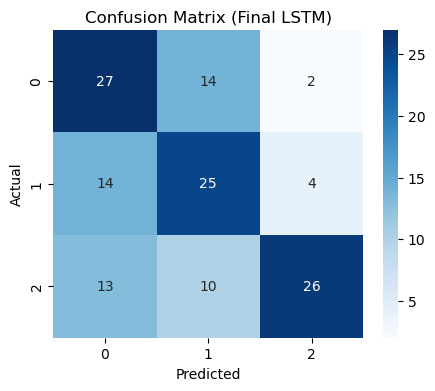

In [ ]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, cohen_kappa_score
)
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_prob = final_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")

qwk = cohen_kappa_score(y_test, y_pred, weights="quadratic")
print("Quadratic Weighted Kappa:", qwk)

print("Accuracy:", acc)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
print("Precision (macro):", precision)
print("Recall (macro):", recall)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Final LSTM)")
plt.show()

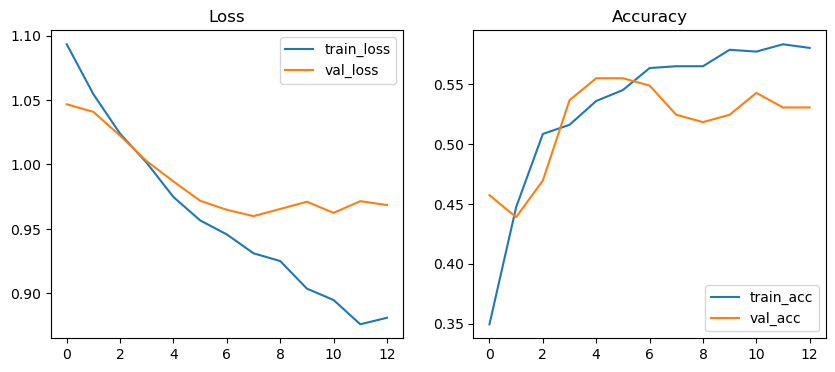

In [49]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy")

plt.show()